# 09 - Rami Whisper (livello di frame) ed ECAPA-TDNN congelati: singoli e fusione tardiva

Secondo e terzo componente dell'architettura, addestrati **da soli** e poi **fusi**, su ASVspoof 2019 LA
(train per l'addestramento, dev per validazione e misura).

**Ingresso:** output del notebook 08 (`ptm_features_train`, `ptm_features_dev`), modelli **congelati**:
- **Whisper-base, encoder, ultimo layer, livello di frame:** sequenza `(T, 512)`, un frame ogni 20 ms, solo frame reali;
- **ECAPA-TDNN (`speechbrain/spkrec-ecapa-voxceleb`), livello di file:** embedding da 192 valori, **grezzi**
  (nessuna normalizzazione L2: la magnitudine dell'embedding viene lasciata al modello, la scelta sara' valutata
  sulle metriche finali).

**Varianti (griglia chiusa, decisa prima di guardare i risultati):**
- **W**: solo ramo Whisper a livello di frame;
- **E**: solo ramo ECAPA a livello di file;
- **WE**: fusione tardiva (variante A): ogni ramo produce il proprio embedding da 50, BatchNorm su ciascun
  embedding, concatenazione (100) e MLP di classificazione.

**Architettura del ramo Whisper** (stessa spina dorsale del ramo prosodico del notebook 06, cambia solo
il numero di canali in ingresso, 512 invece di 8/16/24):
```
Conv1D 256, k=3 -> BN -> ReLU -> Dropout 0,2
Conv1D 128, k=3 -> BN -> ReLU -> Dropout 0,2
LSTM 100 (sequenza) -> BN -> Dropout 0,2
LSTM 50 (sequenza) -> BN
Attention additiva con maschera -> embedding 50
```
**Architettura del ramo ECAPA:** `Linear 192->128 -> BN -> ReLU -> Dropout -> Linear 128->50` (embedding 50).

**Testa di classificazione (identica in tutte le varianti):** `Linear(d, 50) -> ReLU -> Dropout -> Linear(50, 1)`,
con `d = 50` per W ed E, `d = 100` per WE. Uscita = logit bona fide.

**Preprocessing:** standardizzazione per dimensione (media e deviazione standard calcolate **solo sul train**):
per Whisper sui soli frame reali del train, per ECAPA sui 25.380 embedding del train. Nessuna statistica
calcolata sul dev.

**Training (identico al notebook 06):** Adam (lr 0,001), batch 32, BCE pesata (`pos_weight` = spoof/bona fide
del train), massimo 40 epoche, `ReduceLROnPlateau` (0,5, pazienza 3) sulla loss del dev, early stopping sulla
**loss del dev** (pazienza 10), si tiene il checkpoint con la loss del dev piu' bassa. **3 semi** per variante.

**Metriche:** EER e curva DET con le funzioni **ufficiali ASVspoof 2021** (`eval_metrics.py`, stesso file e stesso
SHA256 del notebook 06). AUC con `roc_auc_score` di scikit-learn, dichiarata come metrica **non ASVspoof**.



In [1]:

import os, json, time, copy, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, PackedSequence


TRAIN_DIR = "/kaggle/input/datasets/angelopaldino/outputtrain-feature-noft/ptm_features_train"
DEV_DIR   = "/kaggle/input/notebooks/angelopaldino/deepfakedetection/ptm_features_dev"

INPUT_ROOT = Path(os.environ.get("INPUT_ROOT", "/kaggle/input"))
OUT_DIR = Path(os.environ.get("OUT_DIR", "/kaggle/working/branch_whisper_ecapa"))
OUT_DIR.mkdir(parents=True, exist_ok=True)

VARIANTS = ["W", "E", "WE"]          # W = Whisper frame, E = ECAPA file, WE = fusione tardiva
SEEDS = [0]
MAX_EPOCHS = int(os.environ.get("MAX_EPOCHS", 40))
PATIENCE = int(os.environ.get("PATIENCE", 10))
LR_FACTOR, LR_PATIENCE = 0.5, 3
BATCH_SIZE, LR, DROPOUT = 32, 1e-3, 0.2
EVAL_BATCH = 64
N_BOOT = 1000
SAVE_ATTENTION = False               # pesi di attention del ramo W sul dev (utili per l'analisi del silenzio)
D_WHISPER, D_ECAPA = 512, 192
EMB_DIM = 50
EXPECTED_ROWS = {"train": 25380, "dev": 24844}


STORE_DTYPE = np.float32

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
print("device:", DEVICE, "| torch", torch.__version__, "| dtype di memoria:", np.dtype(STORE_DTYPE).name)

device: cuda | torch 2.10.0+cu128 | dtype di memoria: float32


In [2]:

import sys, hashlib, importlib.util, urllib.request

EVAL_METRICS_PATH = None
EVAL_METRICS_URL = "https://raw.githubusercontent.com/asvspoof-challenge/2021/main/eval-package/eval_metrics.py"

if EVAL_METRICS_PATH is None:
    EVAL_METRICS_PATH = OUT_DIR / "eval_metrics.py"
    if not EVAL_METRICS_PATH.exists():
        urllib.request.urlretrieve(EVAL_METRICS_URL, EVAL_METRICS_PATH)
EVAL_METRICS_PATH = Path(EVAL_METRICS_PATH)
spec = importlib.util.spec_from_file_location("asvspoof_eval_metrics", EVAL_METRICS_PATH)
asv_metrics = importlib.util.module_from_spec(spec); spec.loader.exec_module(asv_metrics)
EVAL_METRICS_SHA256 = hashlib.sha256(EVAL_METRICS_PATH.read_bytes()).hexdigest()
print("eval_metrics.py:", EVAL_METRICS_PATH, "| sha256", EVAL_METRICS_SHA256[:16], "...")

def compute_eer(y, s):
    # EER ufficiale ASVspoof: y = 1 bona fide, 0 spoof; s = punteggio (alto = bona fide)
    y, s = np.asarray(y), np.asarray(s, dtype=np.float64)
    eer, _ = asv_metrics.compute_eer(s[y == 1], s[y == 0])
    return float(eer)

# controllo rapido: punteggi perfettamente separati -> EER 0; punteggi invertiti -> EER 1
assert compute_eer([1, 1, 0, 0], [2.0, 3.0, 0.0, 1.0]) == 0.0
assert compute_eer([1, 1, 0, 0], [0.0, 1.0, 2.0, 3.0]) == 1.0

eval_metrics.py: /kaggle/working/branch_whisper_ecapa/eval_metrics.py | sha256 70c5d2fe8fab6654 ...


## Caricamento delle feature

Gli shard di Whisper vengono concatenati in un unico array in memoria (nessun padding: le sequenze sono
memorizzate una dopo l'altra e gli offset le delimitano, come nel notebook 08). Controlli fatti:

- numero di file per partizione uguale a quello atteso;
- `utt_id` degli shard **identici e nello stesso ordine** di `index_<split>.csv` (non si assume l'ordine: si verifica);
- numero di frame concatenati uguale alla somma di `n_frames`;
- assenza di valori non finiti.

In [3]:

def find_split_dir(split, given):
    if given:
        return Path(given)
    hits = []
    for dirpath, dirnames, filenames in os.walk(INPUT_ROOT):
        dirnames[:] = [d for d in dirnames if d != "flac"]
        if f"index_{split}.csv" in filenames and f"meta_{split}.json" in filenames:
            hits.append(Path(dirpath))
    assert len(hits) == 1, f"Cartella {split} non trovata o ambigua: {hits}. Imposta TRAIN_DIR / DEV_DIR."
    return hits[0]

def load_split(split, given):
    d = find_split_dir(split, given)
    idx = pd.read_csv(d / f"index_{split}.csv")
    meta = json.loads((d / f"meta_{split}.json").read_text())
    assert len(idx) == EXPECTED_ROWS[split], (split, len(idx), EXPECTED_ROWS[split])

    lens = idx["n_frames"].to_numpy().astype(np.int64)
    offsets = np.concatenate([[0], np.cumsum(lens)]).astype(np.int64)
    n_frames_tot = int(offsets[-1])
    gb = n_frames_tot * D_WHISPER * np.dtype(STORE_DTYPE).itemsize / 1e9
    print(f"{split}: {len(idx)} file | {n_frames_tot:,} frame | {gb:.2f} GB in memoria | cartella {d}")

    X = np.empty((n_frames_tot, D_WHISPER), dtype=STORE_DTYPE)
    shards = sorted(d.glob(f"whisper_{split}_shard*.npz"))
    assert len(shards) == meta["n_shards"], (len(shards), meta["n_shards"])
    utt, pos, nonfinite = [], 0, []
    for p in shards:
        z = np.load(p, allow_pickle=True)
        x = z["X"]
        if not np.isfinite(x).all():
            nonfinite.append(p.name)
        X[pos:pos + len(x)] = x
        pos += len(x)
        utt.append(z["utt_id"])
        del z, x
    utt = np.concatenate(utt)
    assert pos == n_frames_tot, (pos, n_frames_tot)
    assert (utt == idx["utt_id"].to_numpy()).all(), "Ordine degli utt_id diverso da index_<split>.csv"

    z = np.load(d / f"ecapa_{split}.npz", allow_pickle=True)
    assert (z["utt_id"] == idx["utt_id"].to_numpy()).all()
    ecapa = z["ecapa"].astype(np.float32)
    assert np.isfinite(ecapa).all()
    assert not nonfinite, nonfinite

    return {"dir": str(d), "meta": meta, "index": idx, "X": X, "offsets": offsets, "lens": lens,
            "ecapa": ecapa, "y": idx["y_bonafide"].to_numpy().astype(np.float32),
            "attack": idx["attack"].to_numpy(), "utt": idx["utt_id"].to_numpy()}

DATA = {"train": load_split("train", TRAIN_DIR), "dev": load_split("dev", DEV_DIR)}
for s, sp in DATA.items():
    L = sp["lens"]
    print(f"{s}: bona fide {int(sp['y'].sum())} | spoof {int((1 - sp['y']).sum())} | "
          f"frame min {L.min()}, mediana {np.median(L):.0f}, max {L.max()}")
print("Norma L2 media degli embedding ECAPA grezzi (train): %.3f" % np.linalg.norm(DATA["train"]["ecapa"], axis=1).mean())

train: 25380 file | 4,360,261 frame | 8.93 GB in memoria | cartella /kaggle/input/datasets/angelopaldino/outputtrain-feature-noft/ptm_features_train
dev: 24844 file | 4,333,067 frame | 8.87 GB in memoria | cartella /kaggle/input/notebooks/angelopaldino/deepfakedetection/ptm_features_dev
train: bona fide 2580 | spoof 22800 | frame min 33, mediana 161, max 660
dev: bona fide 2548 | spoof 22296 | frame min 35, mediana 164, max 580
Norma L2 media degli embedding ECAPA grezzi (train): 330.284


In [4]:

def fit_standardizer(X, chunk=100_000):
    s = np.zeros(X.shape[1], dtype=np.float64)
    ss = np.zeros(X.shape[1], dtype=np.float64)
    n = 0
    for i in range(0, len(X), chunk):
        b = X[i:i + chunk].astype(np.float64)
        s += b.sum(0); ss += (b * b).sum(0); n += len(b)
    mean = s / n
    var = np.maximum(ss / n - mean * mean, 0.0)
    std = np.sqrt(var)
    std[std < 1e-6] = 1.0           # dimensioni costanti: nessun riscalamento
    return mean.astype(np.float32), std.astype(np.float32), n

def apply_standardizer(X, mean, std, chunk=100_000):
    for i in range(0, len(X), chunk):
        X[i:i + chunk] = ((X[i:i + chunk].astype(np.float32) - mean) / std).astype(X.dtype)

t0 = time.perf_counter()
W_MEAN, W_STD, n_used = fit_standardizer(DATA["train"]["X"])
E_MEAN, E_STD, _ = fit_standardizer(DATA["train"]["ecapa"])
for s in ["train", "dev"]:
    apply_standardizer(DATA[s]["X"], W_MEAN, W_STD)
    DATA[s]["ecapa"] = (DATA[s]["ecapa"] - E_MEAN) / E_STD
(OUT_DIR / "standardizer.json").write_text(json.dumps(
    {"whisper_mean": W_MEAN.tolist(), "whisper_std": W_STD.tolist(),
     "ecapa_mean": E_MEAN.tolist(), "ecapa_std": E_STD.tolist(),
     "frames_train_used": int(n_used), "fit_on": "solo train"}, indent=1))
print(f"Statistiche calcolate su {n_used:,} frame reali del train in {time.perf_counter() - t0:.0f} s")
print("Whisper train dopo standardizzazione: media %.4f | dev.std %.4f" %
      (DATA["train"]["X"][:200000].mean(), DATA["train"]["X"][:200000].std()))
print("ECAPA train dopo standardizzazione: media %.4f | dev.std %.4f" %
      (DATA["train"]["ecapa"].mean(), DATA["train"]["ecapa"].std()))

Statistiche calcolate su 4,360,261 frame reali del train in 42 s
Whisper train dopo standardizzazione: media -0.0001 | dev.std 0.9655
ECAPA train dopo standardizzazione: media 0.0000 | dev.std 1.0000


In [5]:

def batch_inputs(sp, idx, need_whisper):
    L = torch.from_numpy(sp["lens"][idx])
    Bw = None
    if need_whisper:
        m = int(L.max())
        Bw = torch.zeros(len(idx), m, D_WHISPER)
        off, lens, X = sp["offsets"], sp["lens"], sp["X"]
        for k, i in enumerate(idx):
            n = int(lens[i])
            Bw[k, :n] = torch.from_numpy(X[off[i]:off[i] + n])
    Be = torch.from_numpy(sp["ecapa"][idx])
    return Bw, L, Be

_bw, _l, _be = batch_inputs(DATA["dev"], np.array([0, 1, 2]), True)
print("Esempio di batch:", tuple(_bw.shape), tuple(_l.tolist()), tuple(_be.shape))
del _bw, _l, _be

Esempio di batch: (3, 271, 512) (271, 164, 164) (3, 192)


In [6]:

def masked_bn(x, mask, bn):
    # BatchNorm sui soli passi reali. x: (B, T, C), mask: (B, T)
    y = torch.zeros_like(x)
    y[mask] = bn(x[mask])
    return y

def map_packed(p, fn):
    return PackedSequence(fn(p.data), p.batch_sizes, p.sorted_indices, p.unsorted_indices)

class WhisperBranch(nn.Module):
    # 1D-CNN (senza pooling) -> LSTM -> attention con maschera. Uscita: embedding da 50
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.conv1, self.bn_c1 = nn.Conv1d(n_in, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256)
        self.conv2, self.bn_c2 = nn.Conv1d(256, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128)
        self.drop = nn.Dropout(p)
        self.lstm1, self.bn_l1 = nn.LSTM(128, 100, batch_first=True), nn.BatchNorm1d(100)
        self.lstm2, self.bn_l2 = nn.LSTM(100, 50, batch_first=True), nn.BatchNorm1d(50)
        self.att_w, self.att_v = nn.Linear(50, 50), nn.Linear(50, 1, bias=False)
        self.out_dim = EMB_DIM

    def conv_block(self, h, conv, bn, mask):
        h = conv(h.transpose(1, 2)).transpose(1, 2)
        h = F.relu(masked_bn(h, mask, bn))
        return self.drop(h) * mask.unsqueeze(-1)

    def forward(self, x, lengths):
        T = x.shape[1]
        mask = torch.arange(T, device=x.device)[None, :] < lengths.to(x.device)[:, None]
        h = self.conv_block(x, self.conv1, self.bn_c1, mask)
        h = self.conv_block(h, self.conv2, self.bn_c2, mask)
        p = pack_padded_sequence(h, lengths.cpu(), batch_first=True, enforce_sorted=False)
        p, _ = self.lstm1(p)
        p = map_packed(map_packed(p, self.bn_l1), self.drop)
        p, _ = self.lstm2(p)
        p = map_packed(p, self.bn_l2)
        H, _ = pad_packed_sequence(p, batch_first=True, total_length=T)
        e = self.att_v(torch.tanh(self.att_w(H))).squeeze(-1)
        a = torch.softmax(e.masked_fill(~mask, float("-inf")), dim=1)
        return (a.unsqueeze(-1) * H).sum(1), a

class EcapaBranch(nn.Module):
    # MLP sull'embedding a livello di file (192). Uscita: embedding da 50
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, 128), nn.BatchNorm1d(128), nn.ReLU(),
                                 nn.Dropout(p), nn.Linear(128, EMB_DIM))
        self.out_dim = EMB_DIM

    def forward(self, x):
        return self.net(x)

class Detector(nn.Module):
    def __init__(self, variant, p=DROPOUT):
        super().__init__()
        self.variant = variant
        self.use_w = variant in ("W", "WE")
        self.use_e = variant in ("E", "WE")
        d = 0
        if self.use_w:
            self.wb = WhisperBranch(D_WHISPER, p); d += self.wb.out_dim
        if self.use_e:
            self.eb = EcapaBranch(D_ECAPA, p); d += self.eb.out_dim
        # BatchNorm solo in fusione, per rendere confrontabili le scale dei due embedding
        self.fuse = variant == "WE"
        if self.fuse:
            self.bn_w, self.bn_e = nn.BatchNorm1d(EMB_DIM), nn.BatchNorm1d(EMB_DIM)
        self.head = nn.Sequential(nn.Linear(d, 50), nn.ReLU(), nn.Dropout(p), nn.Linear(50, 1))

    def forward(self, xw, lengths, xe):
        parts, a = [], None
        if self.use_w:
            zw, a = self.wb(xw, lengths)
            parts.append(self.bn_w(zw) if self.fuse else zw)
        if self.use_e:
            ze = self.eb(xe)
            parts.append(self.bn_e(ze) if self.fuse else ze)
        z = torch.cat(parts, dim=1) if len(parts) > 1 else parts[0]
        return self.head(z).squeeze(-1), a

for v in VARIANTS:
    n_par = sum(p.numel() for p in Detector(v).parameters())
    print(f"Variante {v}: {n_par:,} parametri")

Variante W: 620,573 parametri
Variante E: 34,011 parametri
Variante WE: 654,683 parametri


In [7]:

Y_TR, Y_DEV, ATTACK_DEV = DATA["train"]["y"], DATA["dev"]["y"], DATA["dev"]["attack"]
POS_W = float((Y_TR == 0).sum() / (Y_TR == 1).sum())
print("pos_weight (train):", round(POS_W, 4))

def evaluate(model, sp, y, loss_fn, need_whisper, bs=EVAL_BATCH, want_att=False):
    model.eval()
    scores, att, tot = [], [], 0.0
    with torch.no_grad():
        for k in range(0, len(y), bs):
            idx = np.arange(k, min(k + bs, len(y)))
            Bw, L, Be = batch_inputs(sp, idx, need_whisper)
            out, a = model(Bw.to(DEVICE) if need_whisper else None, L, Be.to(DEVICE))
            tot += loss_fn(out, torch.from_numpy(y[idx]).to(DEVICE)).item() * len(idx)
            scores.append(out.cpu().numpy())
            if want_att and a is not None:
                att += [a[i, :int(L[i])].cpu().numpy() for i in range(len(idx))]
    return tot / len(y), np.concatenate(scores), att

def train_run(variant, seed):
    need_whisper = variant in ("W", "WE")
    torch.manual_seed(seed); np.random.seed(seed)
    model = Detector(variant).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_W, device=DEVICE))
    ytr_t = torch.from_numpy(Y_TR)
    g = np.random.default_rng(seed)
    best = {"loss": np.inf, "epoch": 0, "state": None}
    hist, bad = [], 0
    for ep in range(1, MAX_EPOCHS + 1):
        model.train(); tr_loss, n = 0.0, 0
        perm = g.permutation(len(Y_TR))
        for k in range(0, len(perm), BATCH_SIZE):
            b = perm[k:k + BATCH_SIZE]
            if len(b) < 2:
                continue
            Bw, L, Be = batch_inputs(DATA["train"], b, need_whisper)
            out, _ = model(Bw.to(DEVICE) if need_whisper else None, L, Be.to(DEVICE))
            loss = loss_fn(out, ytr_t[b].to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * len(b); n += len(b)
        dv_loss, dv_scores, _ = evaluate(model, DATA["dev"], Y_DEV, loss_fn, need_whisper)
        hist.append({"variant": variant, "seed": seed, "epoch": ep, "lr": opt.param_groups[0]["lr"],
                     "train_loss": tr_loss / n, "dev_loss": dv_loss,
                     "dev_eer": compute_eer(Y_DEV, dv_scores), "dev_auc": roc_auc_score(Y_DEV, dv_scores)})
        sched.step(dv_loss)
        if dv_loss < best["loss"]:
            best = {"loss": dv_loss, "epoch": ep, "state": copy.deepcopy(model.state_dict())}; bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    model.load_state_dict(best["state"])
    _, scores, att = evaluate(model, DATA["dev"], Y_DEV, loss_fn, need_whisper, want_att=SAVE_ATTENTION)
    return model, scores, att, hist, best["epoch"], ep

RES, HIST = OUT_DIR / "results.csv", OUT_DIR / "history.csv"
rows = pd.read_csv(RES).to_dict("records") if RES.exists() else []
SCORES = {}
t_all = time.perf_counter()
for v in VARIANTS:
    for seed in SEEDS:
        tag = f"{v}_seed{seed}"
        f_sc, f_model = OUT_DIR / f"scores_{tag}.npy", OUT_DIR / f"model_{tag}.pt"
        if f_sc.exists() and f_model.exists() and any(r["variant"] == v and r["seed"] == seed for r in rows):
            SCORES[(v, seed)] = np.load(f_sc)
            continue
        t0 = time.perf_counter()
        model, scores, att, hist, best_ep, last_ep = train_run(v, seed)
        torch.save(model.state_dict(), f_model)
        np.save(f_sc, scores); SCORES[(v, seed)] = scores
        if SAVE_ATTENTION and att:
            a = np.empty(len(att), dtype=object); a[:] = att
            np.savez_compressed(OUT_DIR / f"attention_{tag}.npz", attention=a, utt_id=DATA["dev"]["utt"])
        pd.DataFrame(hist).to_csv(HIST, mode="a", index=False, header=not HIST.exists())
        rows = [r for r in rows if not (r["variant"] == v and r["seed"] == seed)]
        rows.append({"variant": v, "seed": seed, "eer_dev": compute_eer(Y_DEV, scores),
                     "auc_dev": roc_auc_score(Y_DEV, scores),
                     "best_epoch": best_ep, "last_epoch": last_ep, "minutes": (time.perf_counter() - t0) / 60})
        pd.DataFrame(rows).to_csv(RES, index=False)
        r = rows[-1]
        print(f"{v} seed {seed}: EER dev {100 * r['eer_dev']:.2f}% | AUC {r['auc_dev']:.4f} | "
              f"epoca migliore {best_ep}, fermato a {last_ep} | {r['minutes']:.1f} min")
print(f"Totale: {(time.perf_counter() - t_all) / 60:.1f} min")
res = pd.DataFrame(rows).sort_values(["variant", "seed"])
res.assign(eer_dev=(100 * res["eer_dev"]).round(2), auc_dev=res["auc_dev"].round(4), minutes=res["minutes"].round(1))

pos_weight (train): 8.8372
W seed 0: EER dev 0.54% | AUC 0.9997 | epoca migliore 10, fermato a 20 | 20.0 min
E seed 0: EER dev 9.06% | AUC 0.9729 | epoca migliore 1, fermato a 11 | 0.4 min
WE seed 0: EER dev 2.40% | AUC 0.9966 | epoca migliore 1, fermato a 11 | 11.2 min
Totale: 31.6 min


,variant,seed,eer_dev,auc_dev,best_epoch,last_epoch,minutes
1,E,0,9.06,0.9729,1,11,0.4
0,W,0,0.54,0.9997,10,20,20.0
2,WE,0,2.40,0.9966,1,11,11.2


In [8]:

def paired_bootstrap(s_a, s_b, n_boot=N_BOOT, seed=0):
    g = np.random.default_rng(seed)
    ib, is_ = np.where(Y_DEV == 1)[0], np.where(Y_DEV == 0)[0]
    d = []
    for _ in range(n_boot):
        ii = np.concatenate([g.choice(ib, len(ib)), g.choice(is_, len(is_))])
        d.append(compute_eer(Y_DEV[ii], s_a[ii]) - compute_eer(Y_DEV[ii], s_b[ii]))
    return np.percentile(100 * np.array(d), [2.5, 97.5])

summary = res.groupby("variant").agg(eer_mean=("eer_dev", "mean"), eer_std=("eer_dev", "std"),
                                     auc_mean=("auc_dev", "mean"), auc_std=("auc_dev", "std"),
                                     best_epoch_mean=("best_epoch", "mean"), last_epoch_mean=("last_epoch", "mean"),
                                     minutes_mean=("minutes", "mean"))
summary[["eer_mean", "eer_std"]] *= 100
avg = {v: np.mean([SCORES[(v, s)] for s in SEEDS], axis=0) for v in VARIANTS}
summary["eer_score_medio"] = [100 * compute_eer(Y_DEV, avg[v]) for v in summary.index]
summary["auc_score_medio"] = [roc_auc_score(Y_DEV, avg[v]) for v in summary.index]
display(summary.round({"eer_mean": 2, "eer_std": 2, "auc_mean": 4, "auc_std": 4, "best_epoch_mean": 1,
                       "last_epoch_mean": 1, "minutes_mean": 1, "eer_score_medio": 2, "auc_score_medio": 4}))

per_seed = res.pivot(index="seed", columns="variant", values="eer_dev") * 100
display(per_seed.round(2))

PAIRS = [("WE", "W"), ("WE", "E"), ("W", "E")]
cmp_rows = []
for a, b in PAIRS:
    for sd in SEEDS:
        lo_, hi_ = paired_bootstrap(SCORES[(a, sd)], SCORES[(b, sd)], seed=sd)
        cmp_rows.append({"confronto": f"{a}-{b}", "seed": sd,
                         "diff_eer": per_seed.loc[sd, a] - per_seed.loc[sd, b], "ic95_lo": lo_, "ic95_hi": hi_})
    lo_, hi_ = paired_bootstrap(avg[a], avg[b])
    cmp_rows.append({"confronto": f"{a}-{b}", "seed": "punteggio medio",
                     "diff_eer": 100 * (compute_eer(Y_DEV, avg[a]) - compute_eer(Y_DEV, avg[b])),
                     "ic95_lo": lo_, "ic95_hi": hi_})
comparisons = pd.DataFrame(cmp_rows)
comparisons["ic_esclude_zero"] = (comparisons["ic95_lo"] > 0) | (comparisons["ic95_hi"] < 0)
comparisons.to_csv(OUT_DIR / "comparisons.csv", index=False)
display(comparisons.round(2))

,eer_mean,eer_std,auc_mean,auc_std,best_epoch_mean,last_epoch_mean,minutes_mean,eer_score_medio,auc_score_medio
variant,,,,,,,,,
E,9.06,NaN,0.9729,NaN,1.0,11.0,0.4,9.06,0.9729
W,0.54,NaN,0.9997,NaN,10.0,20.0,20.0,0.54,0.9997
WE,2.40,NaN,0.9966,NaN,1.0,11.0,11.2,2.40,0.9966


variant,E,W,WE
seed,,,
0,9.06,0.54,2.4


,confronto,seed,diff_eer,ic95_lo,ic95_hi,ic_esclude_zero
0,WE-W,0,1.86,1.64,2.12,True
1,WE-W,punteggio medio,1.86,1.64,2.12,True
2,WE-E,0,-6.66,-7.22,-6.09,True
3,WE-E,punteggio medio,-6.66,-7.22,-6.09,True
4,W-E,0,-8.52,-9.07,-7.93,True
5,W-E,punteggio medio,-8.52,-9.07,-7.93,True


,A01,A02,A03,A04,A05,A06
variant,,,,,,
W,0.24,0.35,0.24,0.35,0.35,0.78
E,2.83,0.62,3.02,18.10,4.52,10.60
WE,0.91,0.86,1.42,1.29,1.88,5.33


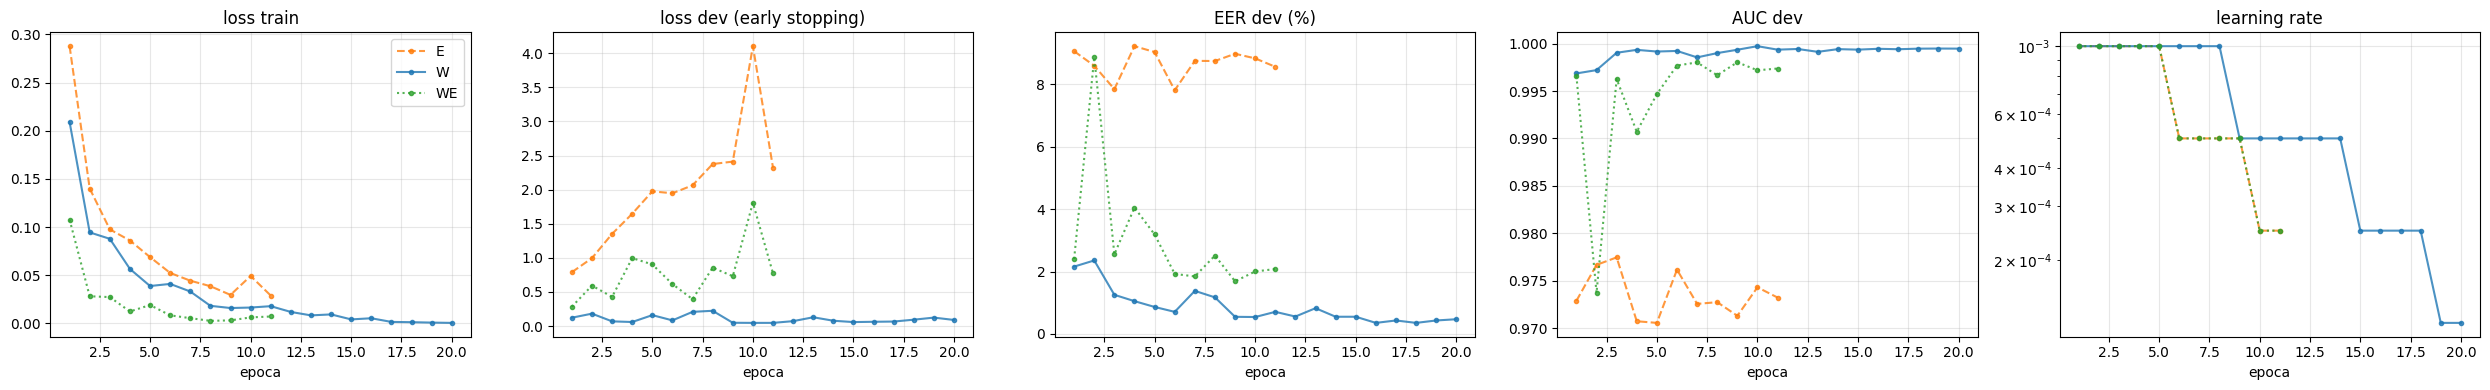

In [9]:

att_rows = []
for v in VARIANTS:
    r = {"variant": v}
    for a in sorted(set(ATTACK_DEV) - {"bonafide"}):
        m = (ATTACK_DEV == "bonafide") | (ATTACK_DEV == a)
        r[a] = round(100 * compute_eer(Y_DEV[m], avg[v][m]), 2)
    att_rows.append(r)
per_attack = pd.DataFrame(att_rows).set_index("variant")
display(per_attack)

h = pd.read_csv(HIST)
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for (v, s), d in h.groupby(["variant", "seed"]):
    k = VARIANTS.index(v)
    kw = dict(color=f"C{k}", ls=["-", "--", ":"][k], alpha=0.8, label=f"{v}" if s == SEEDS[0] else None, marker=".")
    axes[0].plot(d["epoch"], d["train_loss"], **kw)
    axes[1].plot(d["epoch"], d["dev_loss"], **kw)
    axes[2].plot(d["epoch"], 100 * d["dev_eer"], **kw)
    axes[3].plot(d["epoch"], d["dev_auc"], **kw)
    axes[4].plot(d["epoch"], d["lr"], **kw)
axes[4].set_yscale("log")
for ax, t in zip(axes, ["loss train", "loss dev (early stopping)", "EER dev (%)", "AUC dev", "learning rate"]):
    ax.set_title(t); ax.set_xlabel("epoca"); ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "curves.png", dpi=120); plt.show()

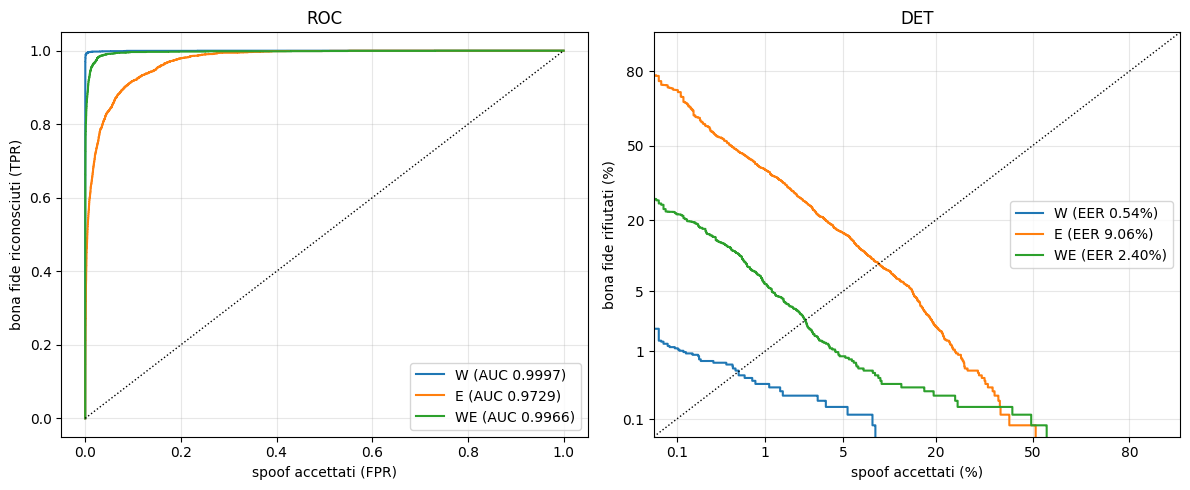

In [10]:

from scipy.stats import norm
_trapz = getattr(np, "trapezoid", None) or np.trapz
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for k, v in enumerate(VARIANTS):
    s_ = avg[v].astype(np.float64)
    frr, far, _ = asv_metrics.compute_det_curve(s_[Y_DEV == 1], s_[Y_DEV == 0])
    fpr, tpr = far[::-1], (1 - frr)[::-1]
    auc_off_curve = float(_trapz(tpr, fpr))
    auc_sk = roc_auc_score(Y_DEV, s_)
    assert abs(auc_off_curve - auc_sk) < 1e-3, (auc_off_curve, auc_sk)
    eer = compute_eer(Y_DEV, s_)
    axes[0].plot(fpr, tpr, color=f"C{k}", label=f"{v} (AUC {auc_sk:.4f})")
    fa, fr = np.clip(far, 1e-4, 1 - 1e-4), np.clip(frr, 1e-4, 1 - 1e-4)
    axes[1].plot(norm.ppf(fa), norm.ppf(fr), color=f"C{k}", label=f"{v} (EER {100 * eer:.2f}%)")
axes[0].plot([0, 1], [0, 1], "k:", lw=1)
axes[0].set_xlabel("spoof accettati (FPR)"); axes[0].set_ylabel("bona fide riconosciuti (TPR)"); axes[0].set_title("ROC")
ticks = np.array([0.001, 0.01, 0.05, 0.2, 0.5, 0.8])
for setter in (axes[1].set_xticks, axes[1].set_yticks):
    setter(norm.ppf(ticks))
axes[1].set_xticklabels([f"{100 * t:g}" for t in ticks]); axes[1].set_yticklabels([f"{100 * t:g}" for t in ticks])
lim = norm.ppf([0.0005, 0.9])
axes[1].plot(lim, lim, "k:", lw=1); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel("spoof accettati (%)"); axes[1].set_ylabel("bona fide rifiutati (%)"); axes[1].set_title("DET")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(OUT_DIR / "roc_det.png", dpi=120); plt.show()

In [11]:

summary_out = {
    "variants": {"W": "solo Whisper, livello di frame (512)",
                 "E": "solo ECAPA, livello di file (192), embedding grezzi senza normalizzazione L2",
                 "WE": "fusione tardiva: embedding 50 + 50, BatchNorm su ciascuno, concatenazione, MLP"},
    "feature_dirs": {s: DATA[s]["dir"] for s in ["train", "dev"]},
    "preprocessing": {"whisper": "standardizzazione per dimensione, statistiche sui soli frame reali del train",
                      "ecapa": "standardizzazione per dimensione, statistiche sul train; nessuna normalizzazione L2",
                      "store_dtype": np.dtype(STORE_DTYPE).name},
    "eer_dev_%": summary.round(3).reset_index().to_dict("records"),
    "eer_per_seed_%": per_seed.round(3).reset_index().to_dict("records"),
    "comparisons": comparisons.round(4).astype({"seed": str}).to_dict("records"),
    "auc_dev": {v: float(roc_auc_score(Y_DEV, avg[v])) for v in VARIANTS},
    "auc_function": "sklearn.metrics.roc_auc_score (metrica non ASVspoof, complementare)",
    "eer_per_attack_%": per_attack.reset_index().to_dict("records"),
    "training": {"max_epochs": MAX_EPOCHS, "patience": PATIENCE, "batch_size": BATCH_SIZE, "lr_initial": LR,
                 "lr_scheduler": {"type": "ReduceLROnPlateau (loss dev)", "factor": LR_FACTOR, "patience": LR_PATIENCE},
                 "dropout": DROPOUT, "pos_weight": POS_W, "seeds": SEEDS,
                 "early_stopping": "loss BCE pesata sul dev", "checkpoint": "loss dev minima", "device": DEVICE},
    "selection_note": ("il dev 2019 e' usato per early stopping, scelta del checkpoint e scelta della variante: "
                       "l'EER riportato sul dev e' selezionato sul dev e non e' una stima non distorta; "
                       "la stima non distorta sara' quella su ASVspoof 2021 DF"),
    "eer_function": {"source": EVAL_METRICS_URL, "sha256": EVAL_METRICS_SHA256}}
_ = (OUT_DIR / "summary.json").write_text(json.dumps(summary_out, indent=2, default=float))
print("Output:", sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()))

Output: ['comparisons.csv', 'curves.png', 'eval_metrics.py', 'history.csv', 'model_E_seed0.pt', 'model_WE_seed0.pt', 'model_W_seed0.pt', 'results.csv', 'roc_det.png', 'scores_E_seed0.npy', 'scores_WE_seed0.npy', 'scores_W_seed0.npy', 'standardizer.json', 'summary.json']
